In [1]:
!unzip -q -o ./data/neoai-2025-cluster-pictures.zip -d ./data/

In [71]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import timm
from torch import nn

import matplotlib.pyplot as plt
import seaborn as sns

## Legend

## Slava's glass. Pt. 3

Slava walked down the corridor, clutching his trophy — the Glass. The twisted halls were behind him, traps dismantled, Bayesian illusions avoided. Ahead — a heavy wooden door with a sign that read "Exit." Freedom. Victory. Light.

But just as he reached for the handle, the air shimmered. The walls groaned, and the scent of chalk filled the space, as if someone had just solved an infinite system of equations.
Out of the shadows stepped Roman — draped in a black robe, a scroll under his arm, and eyes sharp enough to slice through any neural net.

Slava knew him. Knew him from the university days.
They said Roman could prove a theorem before it was even formulated.
They said he could see the loss function of reality.
The Mathematical Mage.

— “Wanna play a game?” Roman asked, and with a flick of his wrist, the Glass vanished from Slava’s hand and reappeared in Roman’s.

— “Not bad. You escaped my labyrinth. But if you want to leave this place with your precious...”
He tossed the glass and caught it casually.

— “You’ll have to impress me.”

From his sleeve, Roman pulled out a deck of old cards. He snapped his fingers — and the deck exploded into glowing fragments, scattering through the room like data points in chaos.

— “Bring me this deck — whole, complete, and intact. Not just gathered. Understood.”

Slava took a deep breath. He knew this was the final challenge. The hardest one.
He opened his laptop, put on his headphones — and in his ears began the final lines of Al Pacino’s legendary speech:

“I mean one-half a step too late, or too early, and you don’t quite make it. One-half second too slow, too fast, you don’t quite catch it. The inches we need are everywhere around us. They’re in every break of the game, every minute, every second. On this team, we fight for that inch. On this team, we tear ourselves and everyone else around us to pieces for that inch. We claw with our fingernails for that inch, because we know when we add up all those inches that’s gonna make the f**** difference between winning and losing! Between livin' and dyin'!”

He hit Enter.

🧩 Your Task:
You are given a set of arrays, where each array represents an image. The images have been augmented. It is known that all data comes from 32 original images, each one followed by several transformed versions.
Your goal is to cluster these arrays.


Slava looked at the scattered card fragments.

— “The game’s not over yet,”.



## Overview

You are given two sets of arrays, **X₁** and **X₂**. Each row in both arrays corresponds to the **same image** (these arrays represent its features). Your task is to cluster the given images. It is known that there are **32 clusters**. Additionally, each original image has been **augmented multiple times**, and the augmented versions have been added to the dataset.

## Metric

[adjusted_rand_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)

## Restriction

If you want to use neural network, you can only use the neural network below - EmbNet. You can't change anything inside the neural network class. You **can't finetune the model** and change the weights.

## sample_submission.csv

Sample_submission consists of a column ID, where the value is the row number in the dataset, and target columns with your predicts of clusters.

===

When you make a submit, make a Quick Save of the notebook, otherwise we may reject your solution.

You must solve this task on KAGGLE (YOU CAN'T USE CLOUD.RU)

=========

## Легенда

## Стекло Славы. Часть 3

Слава шел по коридору, сжимая свой трофей — Стекло. Извращенные залы остались позади, ловушки обезврежены, байесовские иллюзии обойдены стороной. Впереди — тяжелая деревянная дверь с табличкой «Выход». Свобода. Победа. Свет.

Но как только он потянулся к ручке, воздух заискрился. Стены застонали, а в пространстве разнесся запах мела, словно кто-то только что решил бесконечную систему уравнений.  
Из теней вышел Роман — в черном одеянии, со свитком под мышкой и глазами, острыми, словно они могли разрезать любую нейронную сеть.

Слава узнал его. Узнал со студенческих лет.  
Говорили, что Роман мог доказать теорему до того, как она была сформулирована.  
Говорили, что он видел функцию потерь реальности.  
Математический Маг.

— «Хочешь сыграть?» — спросил Роман, и взмахом руки Стекло исчезло из рук Славы и появилось в руках Романа.

— «Неплохо. Ты прошел мой лабиринт. Но если хочешь уйти отсюда со своей драгоценностью...»  
Он бросил Стекло в воздух и ловко поймал.

— «Тебе придется впечатлить меня.»

Из рукава Роман вытащил колоду старых карт. Он щелкнул пальцами — и колода взорвалась светящимися осколками, разлетевшись по комнате, как точки данных в хаосе.

— «Собери эту колоду — целиком, полностью и нетронуто. Не просто собранной. Понял?»

Слава глубоко вдохнул. Он знал, что это финальный вызов. Самый сложный.  
Он открыл ноутбук, надел наушники — и в его ушах зазвучали последние строки легендарной речи Аль Пачино:

«Я имею в виду полшага слишком поздно или слишком рано, и ты не успеваешь. Полсекунды слишком медленно, слишком быстро — ты не успеваешь. Дюймы, которые нам нужны, повсюду вокруг. Они есть в каждом моменте игры, в каждой минуте, в каждой секунде. В этой команде мы боремся за каждый дюйм. В этой команде мы рвем друг друга и всех вокруг ради этого дюйма. Мы царапаем ногтями за этот дюйм, потому что знаем, что когда мы сложим все эти дюймы, это будет иметь **черт возьми** значение между победой и поражением! Между жизнью и смертью!»

Он нажал Enter.

🧩 Ваша задача:
Вам дан набор массивов, где каждый массив представляет изображение. Изображения были аугментированы. Известно, что все данные исходят из 32 исходных изображений, за каждым из которых следуют несколько преобразованных версий.  
Ваша цель — кластеризация этих массивов.

Слава посмотрел на разбросанные осколки карт.

— «Игра еще не окончена», — сказал он.



## Обзор

Вам даны два набора массивов, **X₁** и **X₂**. Каждая строка в обоих массивах соответствует **одному и тому же изображению** (эти массивы представляют его признаки). Ваша задача — кластеризовать заданные изображения. Известно, что кластеров **32**. Кроме того, каждое исходное изображение было **многократно аугментировано**, и эти аугментированные версии были добавлены в набор данных.

## Метрика

[adjusted_rand_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)

## Ограничение

Если вы хотите использовать нейронную сеть, вы можете использовать только нейронную сеть ниже — EmbNet. Вы не можете изменять ничего внутри класса нейронной сети. Вы **не можете дообучать** модель.

## sample_submission.csv

Sample_submission состоит из столбца ID, где значение — номер строки в наборе данных, и столбцов target с вашими предсказаниями кластеров.

===

При отправке решения сделайте Quick Save ноутбука, иначе мы можем отклонить ваше решение.

Вам необходимо решить эту задачу на KAGGLE (ВЫ НЕ МОЖЕТЕ ИСПОЛЬЗОВАТЬ CLOUD.RU)


In [60]:
class EmbNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model("tiny_vit_5m_224.dist_in22k_ft_in1k", pretrained=True, num_classes=0)

    def forward(self, image):
        x = self.model(image)
        return x

In [61]:
def generate_submit(pred_cluster):
    import hashlib
    sub = pd.DataFrame()
    sub['id'] = np.arange(len(pred_cluster))
    sub['target'] = pred_cluster
    hsh = hashlib.sha256(sub.to_csv(index=False).encode('utf-8')).hexdigest()[:8]
    submit_path = f"submit_{hsh}.csv"
    print(f"SUBMIT_NAME: {submit_path}")
    print(sub.head(10))
    sub.to_csv(submit_path, index = None)


X_1 = np.load('./data/data_1.npz')
X_1 = X_1.f.arr_0
X_2 = np.load('./data/data_2.npz')
X_2 = X_2.f.arr_0


In [62]:
X_1.shape, X_2.shape

((3840, 128, 4), (3840, 4, 128))

In [63]:
# X_2 = np.transpose(X_2, (0, 2, 1))

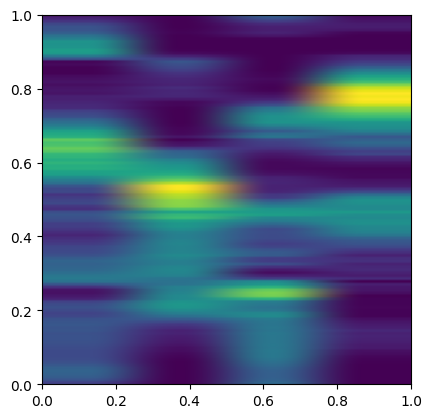

In [64]:
plt.imshow(X_1[0], extent=[0, 1, 0, 1], aspect='equal')

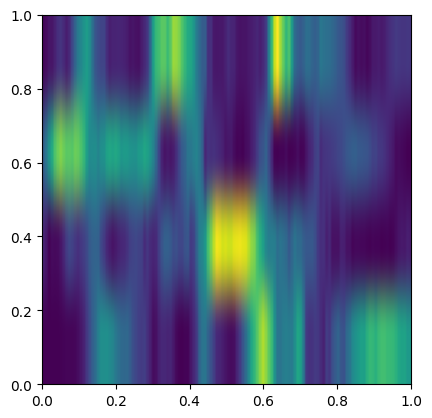

In [65]:
plt.imshow(X_2[0], extent=[0, 1, 0, 1], aspect='equal')

In [76]:
X_1[0]

array([[1.95611954e-01, 4.83600199e-02, 1.12523544e+00, 9.53467041e-02],
       [3.64532620e-01, 1.27944909e-02, 8.98336589e-01, 1.49809957e-01],
       [5.34416616e-01, 5.16968872e-03, 6.35390401e-01, 1.97957650e-01],
       [7.56468952e-01, 3.31204705e-04, 4.15656686e-01, 2.61363387e-01],
       [9.01142001e-01, 1.92572596e-03, 3.01658511e-01, 2.75343299e-01],
       [9.07384038e-01, 1.45105105e-02, 2.98118502e-01, 2.18103781e-01],
       [1.04961753e+00, 3.77357900e-02, 3.37310106e-01, 4.89045382e-02],
       [1.32449162e+00, 9.52263642e-03, 2.10472569e-01, 1.21765621e-02],
       [1.51813495e+00, 6.80009427e-04, 3.88576984e-02, 5.83714526e-03],
       [1.80395639e+00, 1.74648652e-04, 2.36953073e-03, 9.32779221e-04],
       [1.78788948e+00, 6.45199267e-04, 2.09815029e-04, 1.44235732e-04],
       [1.82003784e+00, 7.57853175e-03, 1.92242063e-04, 1.73065194e-03],
       [1.94452429e+00, 2.18573902e-02, 3.61694430e-04, 2.51589920e-02],
       [1.90814495e+00, 8.66997093e-02, 1.30034226e

In [77]:
en = EmbNet()
en(X_1)

model.safetensors:   0%|          | 0.00/21.6M [00:00<?, ?B/s]

TypeError: conv2d() received an invalid combination of arguments - got (numpy.ndarray, Parameter, NoneType, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


In [67]:
X1 = X_1.reshape((X_1.shape[0], X_1.shape[1] * X_1.shape[2]))
X2 = X_2.reshape((X_2.shape[0], X_2.shape[1] * X_2.shape[2]))

X = np.concatenate((X_1.reshape((X_1.shape[0], X_1.shape[1] * X_1.shape[2])), X_2.reshape((X_2.shape[0], X_2.shape[1] * X_2.shape[2]))), 1)

X.shape

(3840, 1024)

In [68]:
pca = PCA(n_components=512)
X = pca.fit_transform(X)

In [ ]:
km = KMeans(32)
# X = np.concatenate((X_1.reshape((X_1.shape[0], X_1.shape[1] * X_1.shape[2])), X_2.reshape((X_2.shape[0], X_2.shape[1] * X_2.shape[2]))), 1)
# X = (X1 + X2) / 2
pred_cluster = km.fit_predict(X)

In [73]:

generate_submit(pred_cluster)

SUBMIT_NAME: submit_8bb3cac9.csv
   id  target
0   0      -1
1   1      -1
2   2      -1
3   3      -1
4   4      -1
5   5      -1
6   6      -1
7   7      -1
8   8      -1
9   9      -1


In [7]:
# When you make a submit, 
# 1. Make a Quick Save of the notebook, otherwise we may reject your solution! 
# 2. Add notebook version to the comment for the submit.

# ===

# При отправке решения:

# 1. Сделайте Quick Save ноутбука, иначе мы можем отклонить ваше решение!
# 2. Добавьте версию ноутбука в комментарий к отправке.